In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=2.2)

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split, ShuffleSplit
from sklearn.metrics import f1_score
import itertools
import lightgbm as lgb
import xgboost as xgb
from xgboost import XGBClassifier
import shap
from tqdm import tqdm
import featuretools as ft
import warnings 
warnings.filterwarnings('ignore')
import time

## 1. 데이터셋 췤

### 1.1 데이터셋 불러올게

In [4]:
df_train = pd.read_csv('/Users/apstat/Desktop/ALCP/KAGGLE 필사/Costa Rican/train.csv')
df_test = pd.read_csv('/Users/apstat/Desktop/ALCP/KAGGLE 필사/Costa Rican/test.csv')

In [5]:
print('df_train shape : ', df_train.shape,'/ df_test shape : ', df_test.shape)

df_train shape :  (9557, 143) / df_test shape :  (23856, 142)


In [6]:
df_train.head()

,Id,v2a1,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,...,SQBescolari,SQBage,SQBhogar_total,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq,Target
0,ID_279628684,190000.0,0,3,0,1,1,0,NaN,0,...,100,1849,1,100,0,1.000000,0.0,100.0,1849,4
1,ID_f29eb3ddd,135000.0,0,4,0,1,1,1,1.0,0,...,144,4489,1,144,0,1.000000,64.0,144.0,4489,4
2,ID_68de51c94,NaN,0,8,0,1,1,0,NaN,0,...,121,8464,1,0,0,0.250000,64.0,121.0,8464,4
3,ID_d671db89c,180000.0,0,5,0,1,1,1,1.0,0,...,81,289,16,121,4,1.777778,1.0,121.0,289,4
4,ID_d56d6f5f5,180000.0,0,5,0,1,1,1,1.0,0,...,121,1369,16,121,4,1.777778,1.0,121.0,1369,4


In [7]:
df_test.head()

,Id,v2a1,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,...,age,SQBescolari,SQBage,SQBhogar_total,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq
0,ID_2f6873615,NaN,0,5,0,1,1,0,NaN,1,...,4,0,16,9,0,1,2.25,0.25,272.25,16
1,ID_1c78846d2,NaN,0,5,0,1,1,0,NaN,1,...,41,256,1681,9,0,1,2.25,0.25,272.25,1681
2,ID_e5442cf6a,NaN,0,5,0,1,1,0,NaN,1,...,41,289,1681,9,0,1,2.25,0.25,272.25,1681
3,ID_a8db26a79,NaN,0,14,0,1,1,1,1.0,0,...,59,256,3481,1,256,0,1.00,0.00,256.00,3481
4,ID_a62966799,175000.0,0,4,0,1,1,1,1.0,0,...,18,121,324,1,0,1,0.25,64.00,NaN,324


훈련데이터에는 target이 있어서 컬럼 하나 더있음

### 1.2 변수 설명

In [10]:
description=[("v2a1","월세납부"),
("hacdor","=1 침실별 과잉 수용"),
("rooms","집 안의 모든 방의 수"),
("hacapo","=1실별 과잉 수용"),
("v14a","=1 가정에 화장실 있음"),
("refrig","=1가구에 냉장고가 있는 경우"),
("v18q","태블릿 소유"),
("v18q1","가구 소유의 태블릿 수"),
("r4h1","12세 미만의 남성"),
("r4h2","남성 12세 이상"),
("r4h3","가구원수합계"),
("r4m1","12세 이하 여성"),
("r4m2","12세 이상 여성"),
("r4m3","가구원 총여성"),
("r4t1","12세 이하인 사람"),
("r4t2","12세 이상"),
("r4t3","가구원 합계"),
("tamhog","가구원수"),
("tamviv","가구원수"),
("escolari","다년간의 교육"),
("rez_esc","학창시절 몇년 뒤"),
("hhsize","가구 크기"),
("paredblolad","=1 외벽의 주요 재료가 블록 또는 벽돌인 경우"),
("paredzocalo","=1 외벽의 주요 재료가 소켓인 경우(목재, 아연 또는 압베스토"),
("paredpreb","=1 외벽의 주요 재료가 사전 조립 또는 시멘트인 경우"),
("pareddes","=1 외벽의 주요 소재가 폐자재일 경우"),
("paredmad","=1 외벽의 주요 재료가 목재인 경우"),
("paredzinc","=1 외벽의 주요 재료가 징크인 경우"),
("paredfibras","=1 외벽의 주요 소재가 천연섬유일 경우"),
("paredother","=1 외벽의 주요 재료가 다른 경우"),
("pisomoscer","=1 바닥의 주요 재료가 모자이크 세라믹 테라조인 경우"),
("pisocemento","=1 바닥의 주요 재료가 시멘트인 경우"),
("pisoother","=1 바닥의 주요 재료가 다른 경우"),
("pisonatur","=1 바닥의 주요 재료가 천연 재료인 경우"),
("pisonotiene","=가정에 층이 없는 경우 1개"),
("pisomadera","=1 바닥의 주요 재료가 목재인 경우"),
("techozinc","=1 지붕의 주요 재료가 금속 포일 또는 징크인 경우"),
("techoentrepiso","=1 지붕의 주요 재료가 섬유 시멘트, 메자닌인 경우 "),
("techocane","=1 지붕의 주요 재료가 천연 섬유인 경우"),
("techootro","=1 지붕의 주요 재료가 다른 경우"),
("cielorazo","=1 집에 천장이 있는 경우"),
("abastaguadentro","=1 주거지 내부의 급수인 경우"),
("abastaguafuera","=1 주거지 외부에 물이 공급되는 경우"),
("abastaguano","=1 물 공급이 없는 경우"),
("public","=CNFL, ICE, ESPH/JASEC에서 나오는 전기 1개"),
("planpri","=민간 발전소에서 나오는 전기 1개"),
("noelec","=1주거지에 전기가 없음"),
("coopele","=협동조합 전기 1개"),
("sanitario1","=1주거지에 화장실 없음"),
("sanitario2","=하수도 또는 하수구에 연결된 화장실 1개"),
("sanitario3","= 정화조에 연결된 화장실 1개"),
("sanitario5","=블랙홀 또는 레트린에 연결된 화장실 1개"),
("sanitario6","=다른 시스템에 연결된 화장실 1개"),
("energcocinar1","=1 요리에 사용되는 주요 에너지원이 없음(주방 없음"),
("energcocinar2","=1 전기 조리에 사용되는 주요 에너지 공급원"),
("energcocinar3","=요리가스에 사용되는 주요 에너지 공급원 1개"),
("energcocinar4","=1 목재 숯 조리에 사용되는 주요 에너지원"),
("elimbasu1","=1 유조선 트럭에 의한 쓰레기 처리의 경우"),
("elimbasu2","=1 주로 식물성 중공 또는 매립에 의한 쓰레기 처리"),
("elimbasu3","=1 주로 불에 태워 폐기물을 처리하는 경우"),
("elimbasu4","=1 빈 공간에 주로 던져서 쓰레기를 처리하는 경우"),
("elimbasu5","=1 주로 강, 하천 또는 바다에 투척하여 쓰레기를 처리하는 경우"),
("elimbasu6","=1 쓰레기 처리가 주로 다른 경우"),
("epared1","=벽이 나쁜 경우 1"),
("epared2","=1 벽이 정규적인 경우"),
("epared3","=벽이 좋은 경우 1개"),
("etecho1","=1 지붕이 나쁜 경우"),
("etecho2","=1 지붕이 정규적인 경우"),
("etecho3","=1 지붕이 양호한 경우"),
("eviv1","=1 바닥이 나쁜 경우"),
("eviv2","=1 바닥이 규칙적인 경우"),
("eviv3","=1 바닥이 좋은 경우"),
("dis","=1 장애인일 경우"),
("male","=1 남성일 경우"),
("female","=1 여성인 경우"),
("estadocivil1","=10세 미만인 경우 1개"),
("estadocivil2","=자유 또는 커플링된 경우 1개"),
("estadocivil3","=결혼한 경우 1개"),
("estadocivil4","=이혼한 경우 1개"),
("estadocivil5","=1 별거한 경우"),
("estadocivil6","=과부 경우 1개"),
("estadocivil7","=싱글일 경우 1개"),
("parentesco1","=가정의 가장일의 경우 1개"),
("parentesco2","=배우자/파트너일 경우 1개"),
("parentesco3","=아들/딸일 경우 1개"),
("parentesco4","=의붓아들/딸 일 경우"),
("parentesco5","=법률상 아들/딸일 경우 1개"),
("parentesco6","=손자/손자일 경우"),
("parentesco7","=어머니/아버지인 경우"),
("parentesco8","=법률상 아버지/어머니일 경우 1개"),
("parentesco9","=형/동생인 경우 1개"),
("parentesco10","=법률상 형제/자매인 경우 1개"),
("parentesco11","=1 다른 가족 구성원의 경우"),
("parentesco12","=1 가족이 아닌 다른 구성원의 경우"),
("idhogar","가구 수준 식별자"),
("hogar_nin","0~19세인 가구원 수 "),
("hogar_adul","어른인 가구원수"),
("hogar_mayor","65세 이상인 가구원수 "),
("hogar_total","가구원 총 인원수"),
("dependency","종속율"),
("edjefe","남성 가장의 수년간 교육"),
("edjefa","여성 가장의 수년간 교육"),
("meaneduc","평균 성인 교육년(18+)"),
("instlevel1","=1 교육 수준 없음"),
("instlevel2","=1 불완전한 초등교육"),
("instlevel3","=1 완전한 초등교육"),
("instlevel4","=1 불완전한 학업 2차 수준"),
("instlevel5","=1 완전한 학문적 2차 수준"),
("instlevel6","=1 불완전한 기술 2차 수준"),
("instlevel7","=1 완전한 기술 2차 수준"),
("instlevel8","=1학부 이상"),
("instlevel9","=1 대학원 고등교육"),
("bedrooms","침실 수"),
("overcrowding","# 객실당 인원수"),
("tipovivi1","=1자체 및 완전유급주택"),
("tipovivi2","=1개 소유, 할부 결제"),
("tipovivi3","=1 임대"),
("tipovivi4","=1 불안정한"),
("tipovivi5","=1 다른사람에게 할당된"),
("computer","=1 가구에 노트북 또는 데스크탑 컴퓨터가 있는 경우, 대여"),
("television","=1가구에 TV가 있는 경우"),
("mobilephone","=휴대전화일 경우 1"),
("qmobilephone","휴대전화 번호"),
("lugar1","=1 지역 중심"),
("lugar2","=1 지역 Chorotega"),
("lugar3","=1 지역 PacÃƒÂ­fico central"),
("lugar4","=1 지역 Brunca"),
("lugar5","=1 지역 Huetar AtlÃƒÂ¡ntica"),
("lugar6","=1 지역 Huetar Norte"),
("area1","=1 조나 우르바나"),
("area2","=2 조나 시골"),
("age","연령"),
("SQBescolari","에스코라리 제곱"),
("SQBage","나이 제곱"),
("SQBhogar_total","hogar_total 제곱"),
("SQBedjefe","에드제프 제곱"),
("SQBhogar_nin","hogar_nin 제곱"),
("SQBovercrowding","과밀 제곱"),
("SQBdependency","종속성 제곱"),
("SQBmeaned","평균 제곱"),
("agesq","나이 제곱")]

description = pd.DataFrame(description, columns = ['varname', 'description'])

In [11]:
description

,varname,description
0,v2a1,월세납부
1,hacdor,=1 침실별 과잉 수용
2,rooms,집 안의 모든 방의 수
3,hacapo,=1실별 과잉 수용
4,v14a,=1 가정에 화장실 있음
...,...,...
136,SQBhogar_nin,hogar_nin 제곱
137,SQBovercrowding,과밀 제곱
138,SQBdependency,종속성 제곱
139,SQBmeaned,평균 제곱


### 1.3 결측치 확인

In [13]:
total = df_train.isnull().sum().sort_values(ascending = False)
percent = 100 * (df_train.isnull().sum() / df_train.isnull().count()).sort_values(ascending=False)
missing_df = pd.concat([total, percent], axis = 1, keys=['Total', 'Percent'])

missing_df.head(20)

,Total,Percent
rez_esc,7928,82.954902
v18q1,7342,76.823271
v2a1,6860,71.779847
SQBmeaned,5,0.052318
meaneduc,5,0.052318
Id,0,0.000000
hogar_adul,0,0.000000
parentesco10,0,0.000000
parentesco11,0,0.000000
parentesco12,0,0.000000


In [14]:
# 교육이 yes고, 그사람이 가장이면, 교육을 에스콜라리로 채운대
# edjefe : 남성가장 교육기간, edjefa : 여성가장 교육기간, escolari : 교육기간 인듯
# parentesco1 : 가장

df_train.loc[(df_train['edjefa'] == "yes") & (df_train['parentesco1'] == 1), "edjefa"] = df_train.loc[(df_train['edjefa'] == "yes") & (df_train['parentesco1'] == 1), "escolari"]
df_train.loc[(df_train['edjefe'] == "yes") & (df_train['parentesco1'] == 1), "edjefe"] = df_train.loc[(df_train['edjefe'] == "yes") & (df_train['parentesco1'] == 1), "escolari"]

df_test.loc[(df_test['edjefa'] == "yes") & (df_test['parentesco1'] == 1), "edjefa"] = df_test.loc[(df_test['edjefa'] == "yes") & (df_test['parentesco1'] == 1), "escolari"]
df_test.loc[(df_test['edjefe'] == "yes") & (df_test['parentesco1'] == 1), "edjefe"] = df_test.loc[(df_test['edjefe'] == "yes") & (df_test['parentesco1'] == 1), "escolari"]

# 성별이랑 교육기간의 관계가 있겠지만, yes가 뭔지 모르니까 4로 채운대
# 먼 개소리여
df_train.loc[df_train['edjefa'] == "yes", "edjefa"] = 4
df_train.loc[df_train['edjefe'] == "yes", "edjefe"] = 4

df_test.loc[df_test['edjefa'] == "yes", "edjefa"] = 4
df_test.loc[df_test['edjefe'] == "yes", "edjefe"] = 4

# 두 가구주의 최장 교육기간을 기준으로해서 edjef 컬럼 새로 생성
# 근데 타입오류떠서 수정
# edjefa, edjefe 값 중 "yes"인 경우 escolari 값으로 대체 (가장이고 교육기간 있음)
df_train.loc[(df_train['edjefa'] == "yes") & (df_train['parentesco1'] == 1), 'edjefa'] = df_train.loc[(df_train['edjefa'] == "yes") & (df_train['parentesco1'] == 1), 'escolari']
df_train.loc[(df_train['edjefe'] == "yes") & (df_train['parentesco1'] == 1), 'edjefe'] = df_train.loc[(df_train['edjefe'] == "yes") & (df_train['parentesco1'] == 1), 'escolari']

df_test.loc[(df_test['edjefa'] == "yes") & (df_test['parentesco1'] == 1), 'edjefa'] = df_test.loc[(df_test['edjefa'] == "yes") & (df_test['parentesco1'] == 1), 'escolari']
df_test.loc[(df_test['edjefe'] == "yes") & (df_test['parentesco1'] == 1), 'edjefe'] = df_test.loc[(df_test['edjefe'] == "yes") & (df_test['parentesco1'] == 1), 'escolari']

# 나머지 yes/no 처리: 모두 숫자형 아닌 값은 일괄적으로 0으로 처리
df_train['edjefa'] = df_train['edjefa'].replace("yes", 4).replace("no", 0)
df_train['edjefe'] = df_train['edjefe'].replace("yes", 4).replace("no", 0)
df_test['edjefa'] = df_test['edjefa'].replace("yes", 4).replace("no", 0)
df_test['edjefe'] = df_test['edjefe'].replace("yes", 4).replace("no", 0)

# 그 후 숫자형으로 안전하게 변환
df_train["edjefa"] = pd.to_numeric(df_train["edjefa"])
df_train["edjefe"] = pd.to_numeric(df_train["edjefe"])
df_test["edjefa"] = pd.to_numeric(df_test["edjefa"])
df_test["edjefe"] = pd.to_numeric(df_test["edjefe"])

# 최댓값 계산
df_train['edjef'] = df_train[['edjefa','edjefe']].max(axis=1)
df_test['edjef'] = df_test[['edjefa','edjefe']].max(axis=1)

# 화장실 변수 겹쳐서 통일
# v14a : 1 = 화장실 있음 / sanitario : 1 = 화장실 없음 / 
# 인데 왜 이러냐 이거? 1, 0 일때가 v14a 1이고, sanitario 0인거 아님?
# abastaguano : 1 = 물공급 없음 > 물공급 없으면 화장실 없는걸로 취급

# 그럼 이건, 화장실 있는데, 화장실 없는데, 물이 잘나옴 => 화장실 없음? 뭔소릴까? 암튼 패스
df_train.loc[(df_train.v14a ==  1) & (df_train.sanitario1 ==  1) & (df_train.abastaguano == 0), "v14a"] = 0
df_train.loc[(df_train.v14a ==  1) & (df_train.sanitario1 ==  1) & (df_train.abastaguano == 0), "sanitario1"] = 0

df_test.loc[(df_test.v14a ==  1) & (df_test.sanitario1 ==  1) & (df_test.abastaguano == 0), "v14a"] = 0
df_test.loc[(df_test.v14a ==  1) & (df_test.sanitario1 ==  1) & (df_test.abastaguano == 0), "sanitario1"] = 0

rez_esc : 학교에서 뒤쳐진 연수 (유급연수)   
SQBmeaned : 가구내 성인의 평균 교육기간의 제곱   
둘다 결측치는 0으로 채운다~   

In [16]:
df_train['rez_esc'].fillna(0, inplace=True)
df_test['rez_esc'].fillna(0, inplace=True)

In [17]:
df_train['SQBmeaned'].fillna(0, inplace=True)
df_test['SQBmeaned'].fillna(0, inplace=True)

meaneduc : 성인의 교육 평균 기간   
결측치 0으로 처리

In [19]:
df_train['meaneduc'].fillna(0, inplace=True)
df_test['meaneduc'].fillna(0, inplace=True)

v18q : 태블릿 보유 여부   
v18q1 : 가구에 있는 태블릿의 수   
일단 태블릿 수 확인하고, 결측값인 애들(없는애들)은 0으로 채우기

In [21]:
df_train.loc[df_train['v18q'] == 1, 'v18q1'].value_counts()

v18q1
1.0    1586
2.0     444
3.0     129
4.0      37
5.0      13
6.0       6
Name: count, dtype: int64

In [22]:
df_train.loc[df_train['v18q'] == 0, 'v18q1'].value_counts()

Series([], Name: count, dtype: int64)

In [23]:
df_train['v18q1'].fillna(0, inplace=True)
df_test['v18q1'].fillna(0, inplace=True)

v2a1: 월세  
tipovivi3 : 집 렌트 여부 

In [25]:
df_train['tipovivi3'].value_counts()

tipovivi3
0    7821
1    1736
Name: count, dtype: int64

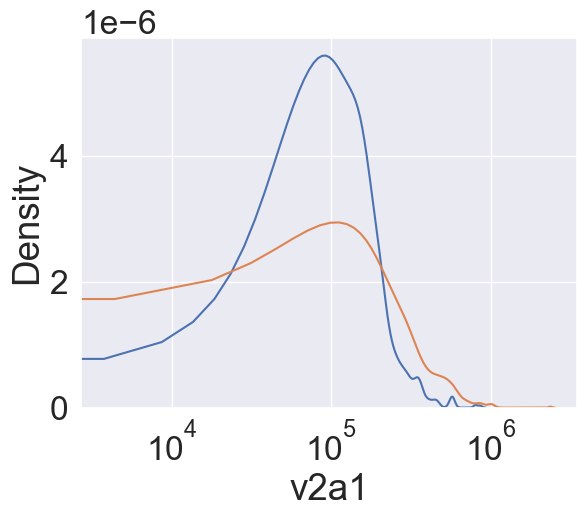

In [26]:
sns.kdeplot(df_train.loc[df_train['tipovivi3'] == 1, 'v2a1'], label='Monthly rent payment of household(rented=1)')
sns.kdeplot(df_train.loc[df_train['tipovivi3'] == 0, 'v2a1'], label='Monthly rent payment of household(rented=0)')
plt.xscale('log')
plt.show()

일단 결측치 0 꼬라박아 (범퍼카 아님)

In [28]:
df_train['v2a1'].fillna(0, inplace=True)
df_test['v2a1'].fillna(0, inplace=True)

대강 전처리 했으니까 다시 확인 ㄱㄱ

In [30]:
total = df_train.isnull().sum().sort_values(ascending=False)
percent = 100 * (df_train.isnull().sum() / df_train.isnull().count()).sort_values(ascending=False)
missing_df = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])

missing_df.head(20)

,Total,Percent
Id,0,0.0
v2a1,0,0.0
parentesco10,0,0.0
parentesco11,0,0.0
parentesco12,0,0.0
idhogar,0,0.0
hogar_nin,0,0.0
hogar_adul,0,0.0
hogar_mayor,0,0.0
hogar_total,0,0.0


오 없는듯?

## 2. 피처 엔지니어링
도메인 지식을 이용해 원자료를 가공하여 특징을 추출하는 작업이다.

### 2.1 오브젝트형

In [34]:
features_object = [col for col in df_train.columns if df_train[col].dtype == 'object']

In [35]:
features_object

['Id', 'idhogar', 'dependency']

저 3개가 오브젝트형임 ㅇㅇ

dependency : 종속율?  
가정 내에서의 특정 구성원의 의존성을 나타냄

In [38]:
# 차피 두 변수 제곱관계니까 통일
df_train['dependency'] = np.sqrt(df_train['SQBdependency'])
df_test['dependency'] = np.sqrt(df_test['SQBdependency'])

edjefe : 남성 가장의 교육 기간   
yes/no로 되어있는것도 있어어 이거는 숫자로 바꿔주기
근데, escolari로 안하고 왜 1,0으로 하지?

In [40]:
def replace_edjefe(x):
    if x == 'yes':
        return 1
    elif x == 'no':
        return 0
    else:
        return x

df_train['edjefe'] = df_train['edjefe'].apply(replace_edjefe).astype(float)
df_test['edjefe'] = df_test['edjefe'].apply(replace_edjefe).astype(float)

마찬가지로   
edjefe : 여성 가장의 교육 기간

In [42]:
def replace_edjefa(x):
    if x == 'yes':
        return 1
    elif x == 'no':
        return 0
    else:
        return x

df_train['edjefa'] = df_train['edjefa'].apply(replace_edjefa).astype(float)
df_test['edjefa'] = df_test['edjefa'].apply(replace_edjefa).astype(float)

In [43]:
# 둘중 최대로 넣는건데, 왜 또 하냐?
df_train['edjef'] = np.max(df_train[['edjefa','edjefe']], axis=1)
df_test['edjef'] = np.max(df_test[['edjefa','edjefe']], axis=1)

지붕이랑 전기 변수를 또 만드네?   
techozinc : 지붕의 주요 재료가 금속 포일 또는 징크인 경우   
techoentrepiso : 지붕의 주요 재료가 섬유 시멘트, 메자닌인 경우   
techocane : 지붕의 주요 재료가 천연 섬유인 경우   
techootro : 지붕의 주요 재료가 다른 경우(나머지인듯)   
이거 싹다 0인거 1로 만들기~   

public : CNFL, ICE, ESPH/JASEC에서 나오는 전기 (뭐 한전느낌인건가)   
planpri : 민간 발전소에서 나오는 전기 1개   
noelec : 주거지에 전기가 없음   
coopele : 협동조합 전기   
아무튼 이거도 다 0인거 1로 만들기 ~

In [45]:
df_train['roof_waste_material'] = np.nan
df_test['roof_waste_material'] = np.nan
df_train['electricity_other'] = np.nan
df_test['electricity_other'] = np.nan

def fill_roof_exception(x):
    if (x['techozinc'] == 0) and (x['techoentrepiso'] == 0) and (x['techocane'] == 0) and (x['techootro'] == 0):
        return 1
    else:
        return 0

def fill_no_electricity(x):
    if (x['public'] == 0) and (x['planpri'] == 0) and (x['noelec'] == 0) and (x['coopele'] == 0):
        return 1
    else:
        return 0

df_train['roof_waste_material'] = df_train.apply(lambda x : fill_roof_exception(x),axis=1)
df_test['roof_waste_material'] = df_test.apply(lambda x : fill_roof_exception(x),axis=1)
df_train['electricity_other'] = df_train.apply(lambda x : fill_no_electricity(x),axis=1)
df_test['electricity_other'] = df_test.apply(lambda x : fill_no_electricity(x),axis=1)

### 2.2 카테고리

In [47]:
binary_cat_features = [col for col in df_train.columns if df_train[col].value_counts().shape[0] == 2]

In [48]:
binary_cat_features

['hacdor',
 'hacapo',
 'v14a',
 'refrig',
 'v18q',
 'paredblolad',
 'paredzocalo',
 'paredpreb',
 'pareddes',
 'paredmad',
 'paredzinc',
 'paredfibras',
 'paredother',
 'pisomoscer',
 'pisocemento',
 'pisoother',
 'pisonatur',
 'pisonotiene',
 'pisomadera',
 'techozinc',
 'techoentrepiso',
 'techocane',
 'techootro',
 'cielorazo',
 'abastaguadentro',
 'abastaguafuera',
 'abastaguano',
 'public',
 'planpri',
 'noelec',
 'coopele',
 'sanitario1',
 'sanitario2',
 'sanitario3',
 'sanitario5',
 'sanitario6',
 'energcocinar1',
 'energcocinar2',
 'energcocinar3',
 'energcocinar4',
 'elimbasu1',
 'elimbasu2',
 'elimbasu3',
 'elimbasu4',
 'elimbasu6',
 'epared1',
 'epared2',
 'epared3',
 'etecho1',
 'etecho2',
 'etecho3',
 'eviv1',
 'eviv2',
 'eviv3',
 'dis',
 'male',
 'female',
 'estadocivil1',
 'estadocivil2',
 'estadocivil3',
 'estadocivil4',
 'estadocivil5',
 'estadocivil6',
 'estadocivil7',
 'parentesco1',
 'parentesco2',
 'parentesco3',
 'parentesco4',
 'parentesco5',
 'parentesco6',
 'pa

싹다 카테고리형이긴해

근데 이 이상한 아저씨가 연속형변수 갖다가 갑자기 새로운 변수를 만든대요. 미친아저씨야..

### 2.3 연속형 변수로 새로운 변수 생성

In [52]:
continuous_features = [col for col in df_train.columns if col not in binary_cat_features]
continuous_features = [col for col in continuous_features if col not in features_object]
continuous_features = [col for col in continuous_features if col not in ['Id', 'Target', 'idhogar']]

In [53]:
print('There are {} continuous features'.format(len(continuous_features)))
for col in continuous_features:
    print('{}: {}'.format(col, description.loc[description['varname'] == col, 'description'].values))

There are 39 continuous features
v2a1: ['월세납부']
rooms: ['집 안의 모든 방의 수']
v18q1: ['가구 소유의 태블릿 수']
r4h1: ['12세 미만의 남성']
r4h2: ['남성 12세 이상']
r4h3: ['가구원수합계']
r4m1: ['12세 이하 여성']
r4m2: ['12세 이상 여성']
r4m3: ['가구원 총여성']
r4t1: ['12세 이하인 사람']
r4t2: ['12세 이상']
r4t3: ['가구원 합계']
tamhog: ['가구원수']
tamviv: ['가구원수']
escolari: ['다년간의 교육']
rez_esc: ['학창시절 몇년 뒤']
hhsize: ['가구 크기']
elimbasu5: ['=1 주로 강, 하천 또는 바다에 투척하여 쓰레기를 처리하는 경우']
hogar_nin: ['0~19세인 가구원 수 ']
hogar_adul: ['어른인 가구원수']
hogar_mayor: ['65세 이상인 가구원수 ']
hogar_total: ['가구원 총 인원수']
edjefe: ['남성 가장의 수년간 교육']
edjefa: ['여성 가장의 수년간 교육']
meaneduc: ['평균 성인 교육년(18+)']
bedrooms: ['침실 수']
overcrowding: ['# 객실당 인원수']
qmobilephone: ['휴대전화 번호']
age: ['연령']
SQBescolari: ['에스코라리 제곱']
SQBage: ['나이 제곱']
SQBhogar_total: ['hogar_total 제곱']
SQBedjefe: ['에드제프 제곱']
SQBhogar_nin: ['hogar_nin 제곱']
SQBovercrowding: ['과밀 제곱']
SQBdependency: ['종속성 제곱']
SQBmeaned: ['평균 제곱']
agesq: ['나이 제곱']
edjef: []


나의 모국어..... 반갑네요

tamhog: ['가구원수']   
tamviv: ['가구원수']   
똑같잖아? 근데 데이터 보면 다르거든? 왜그런지는 모르겠는데, 일단 위에꺼 버려

In [56]:
df_train.drop('tamhog', axis=1, inplace=True)
df_test.drop('tamhog', axis=1, inplace=True)

In [57]:
df_train['edjef'].value_counts()

edjef
6.0     2792
11.0    1150
9.0      723
8.0      474
15.0     473
3.0      459
0.0      435
7.0      413
4.0      400
5.0      398
14.0     328
17.0     278
2.0      278
16.0     247
10.0     207
12.0     185
13.0     155
1.0       65
21.0      48
18.0      22
19.0      18
20.0       9
Name: count, dtype: int64

밑에 제곱된애들있는데, 솔직히 필요없긴하대.   
근데, 몰라 일단 유지한대.

가족관련 변수들   
hogar_nin, hogar_adul, hogar_mayor, hogar_total, r4h1, r4h2, r4h3, r4m1, r4m2, r4m3, r4t1, r4t2, r4t3, tmbhog, tamvid, rez_esc, escolari   
겁나많아서 복붙할게요.   
그래도 다 확인은 해볼게... 

**hogar**   
adul : 성인   
mayor : 65세 이상   
nin : 0-19세   
total : 총원   

**r4**   
r4h1 : 12세 미만의 남성   
r4h2 : 남성 12세 이상   
r4h3 : 가구원 총남성   

r4m1 : 12세 이하 여성   
r4m2 : 12세 이상 여성   
r4m3 : 가구원 총여성   
 
r4t1 : 12세 이하인 사람   
r4t2 : 12세 이상   
r4t3 : 가구원 합계  

In [60]:
df_train['adult'] = df_train['hogar_adul'] - df_train['hogar_mayor']
df_train['dependency_count'] = df_train['hogar_nin'] + df_train['hogar_mayor']
df_train['dependency'] = df_train['dependency_count'] / df_train['adult']
df_train['child_percent'] = df_train['hogar_nin'] / df_train['hogar_total']
df_train['elder_percent'] = df_train['hogar_mayor'] / df_train['hogar_total']
df_train['adult_percent'] = df_train['hogar_adul'] / df_train['hogar_total']
df_train['males_younger_12_years_percent'] = df_train['r4h1'] / df_train['hogar_total']
df_train['males_older_12_years_percent'] = df_train['r4h2'] / df_train['hogar_total']
df_train['males_percent'] = df_train['r4h3'] / df_train['hogar_total']
df_train['females_younger_12_years_percent'] = df_train['r4m1'] / df_train['hogar_total']
df_train['females_older_12_years_percent'] = df_train['r4m2'] / df_train['hogar_total']
df_train['females_percent'] = df_train['r4m3'] / df_train['hogar_total']
df_train['persons_younger_12_years_percent'] = df_train['r4t1'] / df_train['hogar_total']
df_train['persons_older_12_years_percent'] = df_train['r4t2'] / df_train['hogar_total']
df_train['persons_percent'] = df_train['r4t3'] / df_train['hogar_total']

In [61]:
df_test['adult'] = df_test['hogar_adul'] - df_test['hogar_mayor']
df_test['dependency_count'] = df_test['hogar_nin'] + df_test['hogar_mayor']
df_test['dependency'] = df_test['dependency_count'] / df_test['adult']
df_test['child_percent'] = df_test['hogar_nin'] / df_test['hogar_total']
df_test['elder_percent'] = df_test['hogar_mayor'] / df_test['hogar_total']
df_test['adult_percent'] = df_test['hogar_adul'] / df_test['hogar_total']
df_test['males_younger_12_years_percent'] = df_test['r4h1'] / df_test['hogar_total']
df_test['males_older_12_years_percent'] = df_test['r4h2'] / df_test['hogar_total']
df_test['males_percent'] = df_test['r4h3'] / df_test['hogar_total']
df_test['females_younger_12_years_percent'] = df_test['r4m1'] / df_test['hogar_total']
df_test['females_older_12_years_percent'] = df_test['r4m2'] / df_test['hogar_total']
df_test['females_percent'] = df_test['r4m3'] / df_test['hogar_total']
df_test['persons_younger_12_years_percent'] = df_test['r4t1'] / df_test['hogar_total']
df_test['persons_older_12_years_percent'] = df_test['r4t2'] / df_test['hogar_total']
df_test['persons_percent'] = df_test['r4t3'] / df_test['hogar_total']

In [62]:
df_train['males_younger_12_years_in_household_size'] = df_train['r4h1'] / df_train['hhsize']
df_train['males_older_12_years_in_household_size'] = df_train['r4h2'] / df_train['hhsize']
df_train['males_in_household_size'] = df_train['r4h3'] / df_train['hhsize']
df_train['females_younger_12_years_in_household_size'] = df_train['r4m1'] / df_train['hhsize']
df_train['females_older_12_years_in_household_size'] = df_train['r4m2'] / df_train['hhsize']
df_train['females_in_household_size'] = df_train['r4m3'] / df_train['hogar_total']
df_train['persons_younger_12_years_in_household_size'] = df_train['r4t1'] / df_train['hhsize']
df_train['persons_older_12_years_in_household_size'] = df_train['r4t2'] / df_train['hhsize']
df_train['persons_in_household_size'] = df_train['r4t3'] / df_train['hhsize']

In [63]:
df_test['males_younger_12_years_in_household_size'] = df_test['r4h1'] / df_test['hhsize']
df_test['males_older_12_years_in_household_size'] = df_test['r4h2'] / df_test['hhsize']
df_test['males_in_household_size'] = df_test['r4h3'] / df_test['hhsize']
df_test['females_younger_12_years_in_household_size'] = df_test['r4m1'] / df_test['hhsize']
df_test['females_older_12_years_in_household_size'] = df_test['r4m2'] / df_test['hhsize']
df_test['females_in_household_size'] = df_test['r4m3'] / df_test['hogar_total']
df_test['persons_younger_12_years_in_household_size'] = df_test['r4t1'] / df_test['hhsize']
df_test['persons_older_12_years_in_household_size'] = df_test['r4t2'] / df_test['hhsize']
df_test['persons_in_household_size'] = df_test['r4t3'] / df_test['hhsize']

진짜 미친 아저씨야...

hacdor : 침실별 과잉 수용   
hacapo : 방별 과잉 수용?   
아무튼 뭐.. 사람 대비 방의 수 이런거 같음

In [66]:
df_train['overcrowding_room_and_bedroom'] = (df_train['hacdor'] + df_train['hacapo'])/2
df_test['overcrowding_room_and_bedroom'] = (df_test['hacdor'] + df_test['hacapo'])/2

교육기간/나이 랑   
12-19세 수

In [68]:
df_train['escolari_age'] = df_train['escolari']/df_train['age']
df_test['escolari_age'] = df_test['escolari']/df_test['age']

df_train['age_12_19'] = df_train['hogar_nin'] - df_train['r4t1']
df_test['age_12_19'] = df_test['hogar_nin'] - df_test['r4t1']  

**인당**   
휴대폰 수   
태블릿 수   
방 수   
월세

In [70]:
df_train['phones-per-capita'] = df_train['qmobilephone'] / df_train['tamviv']
df_train['tablets-per-capita'] = df_train['v18q1'] / df_train['tamviv']
df_train['rooms-per-capita'] = df_train['rooms'] / df_train['tamviv']
df_train['rent-per-capita'] = df_train['v2a1'] / df_train['tamviv']

In [71]:
df_test['phones-per-capita'] = df_test['qmobilephone'] / df_test['tamviv']
df_test['tablets-per-capita'] = df_test['v18q1'] / df_test['tamviv']
df_test['rooms-per-capita'] = df_test['rooms'] / df_test['tamviv']
df_test['rent-per-capita'] = df_test['v2a1'] / df_test['tamviv']

여기서 나온 가구당 인원이랑, 이미 있는 가구당인원 값이 일치하는 개수 확인 ㄱㄱ

In [73]:
(df_train['hogar_total'] == df_train['r4t3']).sum()

9509

이 노트북은 분석에서 기본적으로 shap을 이용하는데(SHapley Additive exPlanation)   
설명가능한 모델 중 하나..    
학습의 출력 결과를 설명하기 위한 게임이론적인 접근방식.   
각 feature들이 예측값에 어떤 기여를 했는지 확인할 수 있음.   
재밌잖아요? 블랙박스모델보다는... 이해가 가능하니까?   

아무튼 쓸데없는 변수들을 버릴겁니다.

월세를 가족 인원 관련 변수로 나눈 변수 추가

In [76]:
family_size_features = ['adult', 'hogar_adul', 'hogar_mayor', 'hogar_nin', 'hogar_total', 'r4h1', 
                        'r4h2', 'r4h3', 'r4m1', 'r4m2', 'r4m3', 'r4t1', 'r4t2', 'r4t3', 'hhsize']
new_feats = []
for col in family_size_features:
    new_col_name = 'new_{}_per_{}'.format('v2a1', col)
    new_feats.append(new_col_name)
    df_train[new_col_name] = df_train['v2a1'] / df_train[col]
    df_test[new_col_name] = df_test['v2a1'] / df_test[col]

col이 0일수도 있으니께...

In [78]:
for col in new_feats:
    df_train[col].replace([np.inf], np.nan, inplace=True)
    df_train[col].fillna(0, inplace=True)
    
    df_test[col].replace([np.inf], np.nan, inplace=True)
    df_test[col].fillna(0, inplace=True)

이건 방 개수를 나눈거고

In [80]:
new_feats = []
for col in family_size_features:
    new_col_name = 'new_{}_per_{}'.format('rooms', col)
    new_feats.append(new_col_name)
    df_train[new_col_name] = df_train['rooms'] / df_train[col]
    df_test[new_col_name] = df_test['rooms'] / df_test[col]

for col in new_feats:
    df_train[col].replace([np.inf], np.nan, inplace=True)
    df_train[col].fillna(0, inplace=True)
    
    df_test[col].replace([np.inf], np.nan, inplace=True)
    df_test[col].fillna(0, inplace=True)

이거는 침실 수

In [82]:
new_feats = []
for col in family_size_features:
    new_col_name = 'new_{}_per_{}'.format('bedrooms', col)
    new_feats.append(new_col_name)
    df_train[new_col_name] = df_train['bedrooms'] / df_train[col]
    df_test[new_col_name] = df_test['bedrooms'] / df_test[col]

for col in new_feats:
    df_train[col].replace([np.inf], np.nan, inplace=True)
    df_train[col].fillna(0, inplace=True)
    
    df_test[col].replace([np.inf], np.nan, inplace=True)
    df_test[col].fillna(0, inplace=True)

중간 점검

In [84]:
print(df_train.shape, df_test.shape)

(9557, 220) (23856, 219)


태블릿수

In [86]:
new_feats = []
for col in family_size_features:
    new_col_name = 'new_{}_per_{}'.format('v18q1', col)
    new_feats.append(new_col_name)
    df_train[new_col_name] = df_train['v18q1'] / df_train[col]
    df_test[new_col_name] = df_test['v18q1'] / df_test[col]

for col in new_feats:
    df_train[col].replace([np.inf], np.nan, inplace=True)
    df_train[col].fillna(0, inplace=True)
    
    df_test[col].replace([np.inf], np.nan, inplace=True)
    df_test[col].fillna(0, inplace=True)

폰수

In [88]:
new_feats = []
for col in family_size_features:
    new_col_name = 'new_{}_per_{}'.format('qmobilephone', col)
    new_feats.append(new_col_name)
    df_train[new_col_name] = df_train['qmobilephone'] / df_train[col]
    df_test[new_col_name] = df_test['qmobilephone'] / df_test[col]

for col in new_feats:
    df_train[col].replace([np.inf], np.nan, inplace=True)
    df_train[col].fillna(0, inplace=True)
    
    df_test[col].replace([np.inf], np.nan, inplace=True)
    df_test[col].fillna(0, inplace=True)

유급년수

In [90]:
new_feats = []
for col in family_size_features:
    new_col_name = 'new_{}_per_{}'.format('rez_esc', col)
    new_feats.append(new_col_name)
    df_train[new_col_name] = df_train['rez_esc'] / df_train[col]
    df_test[new_col_name] = df_test['rez_esc'] / df_test[col]

for col in new_feats:
    df_train[col].replace([np.inf], np.nan, inplace=True)
    df_train[col].fillna(0, inplace=True)
    
    df_test[col].replace([np.inf], np.nan, inplace=True)
    df_test[col].fillna(0, inplace=True)

In [91]:
df_train['rez_esc_age'] = df_train['rez_esc'] / df_train['age']
df_train['rez_esc_escolari'] = df_train['rez_esc'] / df_train['escolari']

df_test['rez_esc_age'] = df_test['rez_esc'] / df_test['age']
df_test['rez_esc_escolari'] = df_test['rez_esc'] / df_test['escolari']

더 부자일수록 폰이랑 태블릿이 많을거니까, 추가 변수 생성

In [93]:
df_train['tabulet_x_qmobilephone'] = df_train['v18q1'] * df_train['qmobilephone']
df_test['tabulet_x_qmobilephone'] = df_test['v18q1'] * df_test['qmobilephone']

벽, 지붕, 바닥의 상태에 따라서 달라지는 부분이 있을 수 잇으니....   
각자 곱하면 또 무슨 의미있는 변수가 나올것 같다고 하네요~

In [95]:
# 벽 * 지붕
for col1 in ['epared1', 'epared2', 'epared3']:
    for col2 in ['etecho1', 'etecho2', 'etecho3']:
        new_col_name = 'new_{}_x_{}'.format(col1, col2)
        df_train[new_col_name] = df_train[col1] * df_train[col2]
        df_test[new_col_name] = df_test[col1] * df_test[col2]
        
# 벽 * 바닥
for col1 in ['epared1', 'epared2', 'epared3']:
    for col2 in ['eviv1', 'eviv2', 'eviv3']:
        new_col_name = 'new_{}_x_{}'.format(col1, col2)
        df_train[new_col_name] = df_train[col1] * df_train[col2]
        df_test[new_col_name] = df_test[col1] * df_test[col2]

# 지붕 * 바닥
for col1 in ['etecho1', 'etecho2', 'etecho3']:
    for col2 in ['eviv1', 'eviv2', 'eviv3']:
        new_col_name = 'new_{}_x_{}'.format(col1, col2)
        df_train[new_col_name] = df_train[col1] * df_train[col2]
        df_test[new_col_name] = df_test[col1] * df_test[col2]

3개 조합했대

In [97]:
for col1 in ['epared1', 'epared2', 'epared3']:
    for col2 in ['etecho1', 'etecho2', 'etecho3']:
        for col3 in ['eviv1', 'eviv2', 'eviv3']:
            new_col_name = 'new_{}_x_{}_x_{}'.format(col1, col2, col3)
            df_train[new_col_name] = df_train[col1] * df_train[col2] * df_train[col3]
            df_test[new_col_name] = df_test[col1] * df_test[col2] * df_train[col3]

In [98]:
print(df_train.shape, df_test.shape)

(9557, 322) (23856, 321)


전기랑 에너지 변수도 섞어서 에너지 변수로 만들고

In [100]:
for col1 in ['public', 'planpri', 'noelec', 'coopele']:
    for col2 in ['energcocinar1', 'energcocinar2', 'energcocinar3', 'energcocinar4']:
        new_col_name = 'new_{}_x_{}'.format(col1, col2)
        df_train[new_col_name] = df_train[col1] * df_train[col2]
        df_test[new_col_name] = df_test[col1] * df_test[col2]

화장실이랑 쓰레기처리 변수도 섞어서 기타 시설 변수로 만들고

In [102]:
for col1 in ['sanitario1', 'sanitario2', 'sanitario3', 'sanitario5', 'sanitario6']:
    for col2 in ['elimbasu1', 'elimbasu2', 'elimbasu3', 'elimbasu4', 'elimbasu5', 'elimbasu6']:
        new_col_name = 'new_{}_x_{}'.format(col1, col2)
        df_train[new_col_name] = df_train[col1] * df_train[col2]
        df_test[new_col_name] = df_test[col1] * df_test[col2]

화장실이랑 물공급 변수도 섞어서 물변수로 만들고

In [104]:
for col1 in ['abastaguadentro', 'abastaguafuera', 'abastaguano']:
    for col2 in ['sanitario1', 'sanitario2', 'sanitario3', 'sanitario5', 'sanitario6']:
        new_col_name = 'new_{}_x_{}'.format(col1, col2)
        df_train[new_col_name] = df_train[col1] * df_train[col2]
        df_test[new_col_name] = df_test[col1] * df_test[col2]

In [105]:
print(df_train.shape, df_test.shape)

(9557, 383) (23856, 382)


교육이랑 지역 섞어서 교육,지역 변수 만들고

In [107]:
for col1 in ['area1', 'area2']:
    for col2 in ['instlevel1', 'instlevel2', 'instlevel3', 'instlevel4', 'instlevel5', 'instlevel6', 'instlevel7', 'instlevel8', 'instlevel9']:
        new_col_name = 'new_{}_x_{}'.format(col1, col2)
        df_train[new_col_name] = df_train[col1] * df_train[col2]
        df_test[new_col_name] = df_test[col1] * df_test[col2]

지역이랑 교육 또 섞어

In [109]:
for col1 in ['lugar1', 'lugar2', 'lugar3', 'lugar4', 'lugar5', 'lugar6']:
    for col2 in ['instlevel1', 'instlevel2', 'instlevel3', 'instlevel4', 'instlevel5', 'instlevel6', 'instlevel7', 'instlevel8', 'instlevel9']:
        new_col_name = 'new_{}_x_{}'.format(col1, col2)
        df_train[new_col_name] = df_train[col1] * df_train[col2]
        df_test[new_col_name] = df_test[col1] * df_test[col2]

In [110]:
print(df_train.shape, df_test.shape)

(9557, 455) (23856, 454)


티비, 폰, 컴터, 태블릿, 냉장고 => 전자제품 변수

In [112]:
df_train['electronics'] = df_train['computer'] * df_train['mobilephone'] * df_train['television'] * df_train['v18q'] * df_train['refrig']
df_test['electronics'] = df_test['computer'] * df_test['mobilephone'] * df_test['television'] * df_test['v18q'] * df_test['refrig']

df_train['no_appliances'] = df_train['refrig'] + df_train['computer'] + df_train['television'] + df_train['mobilephone']
df_test['no_appliances'] = df_test['refrig'] + df_test['computer'] + df_test['television'] + df_test['mobilephone']

지붕, 바닥, 벽 자재 변수 섞어

In [114]:
for col1 in ['paredblolad', 'paredzocalo', 'paredpreb', 'pareddes', 'paredmad', 'paredzinc', 'paredfibras', 'paredother']:
    for col2 in ['pisomoscer', 'pisocemento', 'pisoother', 'pisonatur', 'pisonotiene', 'pisomadera']:
        new_col_name = 'new_{}_x_{}'.format(col1, col2)
        df_train[new_col_name] = df_train[col1] * df_train[col2]
        df_test[new_col_name] = df_test[col1] * df_test[col2]

for col1 in ['pisomoscer', 'pisocemento', 'pisoother', 'pisonatur', 'pisonotiene', 'pisomadera']:
    for col1 in ['techozinc', 'techoentrepiso', 'techocane', 'techootro']:
        new_col_name = 'new_{}_x_{}'.format(col1, col2)
        df_train[new_col_name] = df_train[col1] * df_train[col2]
        df_test[new_col_name] = df_test[col1] * df_test[col2]
        
for col1 in ['paredblolad', 'paredzocalo', 'paredpreb', 'pareddes', 'paredmad', 'paredzinc', 'paredfibras', 'paredother']:
    for col2 in ['techozinc', 'techoentrepiso', 'techocane', 'techootro']:
        new_col_name = 'new_{}_x_{}'.format(col1, col2)
        df_train[new_col_name] = df_train[col1] * df_train[col2]
        df_test[new_col_name] = df_test[col1] * df_test[col2]        
        
for col1 in ['paredblolad', 'paredzocalo', 'paredpreb', 'pareddes', 'paredmad', 'paredzinc', 'paredfibras', 'paredother']:
    for col2 in ['pisomoscer', 'pisocemento', 'pisoother', 'pisonatur', 'pisonotiene', 'pisomadera']:
        for col3 in ['techozinc', 'techoentrepiso', 'techocane', 'techootro']:
            new_col_name = 'new_{}_x_{}_x_{}'.format(col1, col2, col3)
            df_train[new_col_name] = df_train[col1] * df_train[col2] * df_train[col3]
            df_test[new_col_name] = df_test[col1] * df_test[col2] * df_train[col3]

In [115]:
print(df_train.shape, df_test.shape)

(9557, 733) (23856, 732)


와 변수 개많아졌다.   
벽 자재변수 싹다 섞으면 더 많아지는데, 굳이?

근데, 값이 하나인 변수들은 갖다 버리는게 좋겠지?

In [118]:
cols_with_only_one_value = []
for col in df_train.columns:
    if col == 'Target':
        continue
    if df_train[col].value_counts().shape[0] == 1 or df_test[col].value_counts().shape[0] == 1:
        print(col)
        cols_with_only_one_value.append(col)

elimbasu5
new_planpri_x_energcocinar1
new_planpri_x_energcocinar2
new_planpri_x_energcocinar3
new_planpri_x_energcocinar4
new_noelec_x_energcocinar2
new_sanitario1_x_elimbasu4
new_sanitario1_x_elimbasu5
new_sanitario1_x_elimbasu6
new_sanitario2_x_elimbasu4
new_sanitario2_x_elimbasu5
new_sanitario2_x_elimbasu6
new_sanitario3_x_elimbasu5
new_sanitario5_x_elimbasu4
new_sanitario5_x_elimbasu5
new_sanitario5_x_elimbasu6
new_sanitario6_x_elimbasu2
new_sanitario6_x_elimbasu4
new_sanitario6_x_elimbasu5
new_sanitario6_x_elimbasu6
new_abastaguafuera_x_sanitario6
new_abastaguano_x_sanitario2
new_abastaguano_x_sanitario6
new_paredblolad_x_pisonatur
new_paredblolad_x_pisonotiene
new_paredzocalo_x_pisoother
new_paredzocalo_x_pisonatur
new_paredpreb_x_pisonatur
new_pareddes_x_pisoother
new_pareddes_x_pisonatur
new_paredmad_x_pisoother
new_paredmad_x_pisonatur
new_paredzinc_x_pisoother
new_paredzinc_x_pisonatur
new_paredfibras_x_pisoother
new_paredfibras_x_pisonatur
new_paredfibras_x_pisonotiene
new_p

개많네?   
다 없애

In [120]:
df_train.drop(cols_with_only_one_value, axis=1, inplace=True)
df_test.drop(cols_with_only_one_value, axis=1, inplace=True)

In [121]:
cols_train = np.array(sorted([col for col in df_train.columns if col != 'Target']))
cols_test = np.array(sorted(df_test.columns))

훈련, 테스트셋 컬럼 같은지 확인

In [123]:
(cols_train == cols_test).sum() == len(cols_train)

True

ㅇㅋ 같네

가족변수 집합?

In [126]:
def max_min(x):
    return x.max() - x.min()

In [127]:
agg_train = pd.DataFrame()
agg_test = pd.DataFrame()

for item in tqdm(family_size_features):
    for i, function in enumerate(['mean','std','min','max','sum', 'count', max_min]):
        group_train = df_train[item].groupby(df_train['idhogar']).agg(function)
        group_test = df_test[item].groupby(df_test['idhogar']).agg(function)
        if i == 6:
            new_col = item + '_new_' + 'max_min'
        else:
            new_col = item + '_new_' + function
        agg_train[new_col] = group_train
        agg_test[new_col] = group_test

print('new aggregate train set has {} rows, and {} features'.format(agg_train.shape[0], agg_train.shape[1]))
print('new aggregate test set has {} rows, and {} features'.format(agg_test.shape[0], agg_test.shape[1]))

100%|███████████████████████████████████████████| 15/15 [00:01<00:00,  9.63it/s]

new aggregate train set has 2988 rows, and 105 features
new aggregate test set has 7352 rows, and 105 features


가족변수 관련해서 새로운 변수 생성했네?

In [129]:
aggr_list = ['rez_esc', 'dis', 'male', 'female', 
                  'estadocivil1', 'estadocivil2', 'estadocivil3', 'estadocivil4', 'estadocivil5', 'estadocivil6', 'estadocivil7', 
                  'parentesco2', 'parentesco3', 'parentesco4', 'parentesco5', 'parentesco6', 'parentesco7', 'parentesco8', 'parentesco9', 'parentesco10', 
                  'parentesco11', 'parentesco12',
                  'instlevel1', 'instlevel2', 'instlevel3', 'instlevel4', 'instlevel5', 'instlevel6', 'instlevel7', 'instlevel8', 'instlevel9',
                 'epared1', 'epared2', 'epared3', 'etecho1', 'etecho2', 'etecho3', 'eviv1', 'eviv2', 'eviv3', 'refrig', 'television', 'mobilephone',
            'area1', 'area2', 'v18q', 'edjef']



for item in tqdm(aggr_list):
    for function in ['count', 'sum']:
        group_train = df_train[item].groupby(df_train['idhogar']).agg(function)
        group_test = df_test[item].groupby(df_test['idhogar']).agg(function)
        new_col = item + '_new1_' + function
        agg_train[new_col] = group_train
        agg_test[new_col] = group_test
print('new aggregate train set has {} rows, and {} features'.format(agg_train.shape[0], agg_train.shape[1]))
print('new aggregate test set has {} rows, and {} features'.format(agg_test.shape[0], agg_test.shape[1]))

100%|██████████████████████████████████████████| 47/47 [00:00<00:00, 153.65it/s]

new aggregate train set has 2988 rows, and 199 features
new aggregate test set has 7352 rows, and 199 features


In [130]:
aggr_list = ['escolari', 'age', 'escolari_age', 'dependency', 'bedrooms', 'overcrowding', 'rooms', 'qmobilephone', 'v18q1']

for item in tqdm(aggr_list):
    for function in ['mean','std','min','max','sum', 'count', max_min]:
        group_train = df_train[item].groupby(df_train['idhogar']).agg(function)
        group_test = df_test[item].groupby(df_test['idhogar']).agg(function)
        if i == 6:
            new_col = item + '_new2_' + 'max_min'
        else:
            new_col = item + '_new2_' + function
        agg_train[new_col] = group_train
        agg_test[new_col] = group_test

print('new aggregate train set has {} rows, and {} features'.format(agg_train.shape[0], agg_train.shape[1]))
print('new aggregate test set has {} rows, and {} features'.format(agg_test.shape[0], agg_test.shape[1]))

100%|█████████████████████████████████████████████| 9/9 [00:00<00:00,  9.34it/s]

new aggregate train set has 2988 rows, and 208 features
new aggregate test set has 7352 rows, and 208 features


막 새로운 변수들 생성해..... 왜?

In [132]:
agg_test = agg_test.reset_index()
agg_train = agg_train.reset_index()

train_agg = pd.merge(df_train, agg_train, on='idhogar')
test = pd.merge(df_test, agg_test, on='idhogar')

#fill all na as 0
train_agg.fillna(value=0, inplace=True)
test.fillna(value=0, inplace=True)

print('train shape:', train_agg.shape, 'test shape:', test.shape)

train shape: (9557, 724) test shape: (23856, 723)


In [133]:
aggr_list = ['rez_esc', 'dis', 'male', 'female', 
                  'estadocivil1', 'estadocivil2', 'estadocivil3', 'estadocivil4', 'estadocivil5', 'estadocivil6', 'estadocivil7', 
                  'parentesco2', 'parentesco3', 'parentesco4', 'parentesco5', 'parentesco6', 'parentesco7', 'parentesco8', 'parentesco9', 'parentesco10', 
                  'parentesco11', 'parentesco12',
                  'instlevel1', 'instlevel2', 'instlevel3', 'instlevel4', 'instlevel5', 'instlevel6', 'instlevel7', 'instlevel8', 'instlevel9',
                 'epared1', 'epared2', 'epared3', 'etecho1', 'etecho2', 'etecho3', 'eviv1', 'eviv2', 'eviv3', 'refrig', 'television', 'mobilephone',
            'area1', 'area2', 'v18q', 'edjef']
    
for lugar in ['lugar1', 'lugar2', 'lugar3', 'lugar4', 'lugar5', 'lugar6']:
    group_train = df_train[[lugar, 'idhogar'] + aggr_list].groupby([lugar, 'idhogar']).sum().reset_index()
    group_train.columns = [lugar, 'idhogar'] + ['new3_{}_idhogar_{}'.format(lugar, col) for col in group_train][2:]

    group_test = df_test[[lugar, 'idhogar'] + aggr_list].groupby([lugar, 'idhogar']).sum().reset_index()
    group_test.columns = [lugar, 'idhogar'] + ['new3_{}_idhogar_{}'.format(lugar, col) for col in group_test][2:]

    train_agg = pd.merge(train_agg, group_train, on=[lugar, 'idhogar'])
    test = pd.merge(test, group_test, on=[lugar, 'idhogar'])
    
print('train shape:', train_agg.shape, 'test shape:', test.shape)

train shape: (9557, 1006) test shape: (23856, 1005)


In [134]:
aggr_list = ['rez_esc', 'dis', 'male', 'female', 
                  'estadocivil1', 'estadocivil2', 'estadocivil3', 'estadocivil4', 'estadocivil5', 'estadocivil6', 'estadocivil7', 
                  'parentesco2', 'parentesco3', 'parentesco4', 'parentesco5', 'parentesco6', 'parentesco7', 'parentesco8', 'parentesco9', 'parentesco10', 
                  'parentesco11', 'parentesco12',
                  'instlevel1', 'instlevel2', 'instlevel3', 'instlevel4', 'instlevel5', 'instlevel6', 'instlevel7', 'instlevel8', 'instlevel9',
                 'epared1', 'epared2', 'epared3', 'etecho1', 'etecho2', 'etecho3', 'eviv1', 'eviv2', 'eviv3', 'refrig', 'television', 'mobilephone',
            'area1', 'area2', 'v18q', 'edjef']
    
for lugar in ['lugar1', 'lugar2', 'lugar3', 'lugar4', 'lugar5', 'lugar6']:
    group_train = df_train[[lugar, 'idhogar'] + aggr_list].groupby([lugar, 'idhogar']).sum().reset_index()
    group_train.columns = [lugar, 'idhogar'] + ['new4_{}_idhogar_{}'.format(lugar, col) for col in group_train][2:]

    group_test = df_test[[lugar, 'idhogar'] + aggr_list].groupby([lugar, 'idhogar']).sum().reset_index()
    group_test.columns = [lugar, 'idhogar'] + ['new4_{}_idhogar_{}'.format(lugar, col) for col in group_test][2:]

    train_agg = pd.merge(train_agg, group_train, on=[lugar, 'idhogar'])
    test = pd.merge(test, group_test, on=[lugar, 'idhogar'])
    
print('train shape:', train_agg.shape, 'test shape:', test.shape)

train shape: (9557, 1288) test shape: (23856, 1287)


In [135]:
cols_nums = ['age', 'meaneduc', 'dependency', 
             'hogar_nin', 'hogar_adul', 'hogar_mayor', 'hogar_total',
             'bedrooms', 'overcrowding']

for function in tqdm(['mean','std','min','max','sum', 'count', max_min]):
    for lugar in ['lugar1', 'lugar2', 'lugar3', 'lugar4', 'lugar5', 'lugar6']:
        group_train = df_train[[lugar, 'idhogar'] + aggr_list].groupby([lugar, 'idhogar']).agg(function).reset_index()
        group_train.columns = [lugar, 'idhogar'] + ['new5_{}_idhogar_{}_{}'.format(lugar, col, function) for col in group_train][2:]

        group_test = df_test[[lugar, 'idhogar'] + aggr_list].groupby([lugar, 'idhogar']).agg(function).reset_index()
        group_test.columns = [lugar, 'idhogar'] + ['new5_{}_idhogar_{}_{}'.format(lugar, col, function) for col in group_test][2:]

        train_agg = pd.merge(train_agg, group_train, on=[lugar, 'idhogar'])
        test = pd.merge(test, group_test, on=[lugar, 'idhogar'])
        
print('train shape:', train_agg.shape, 'test shape:', test.shape)

100%|█████████████████████████████████████████████| 7/7 [00:30<00:00,  4.34s/it]

train shape: (9557, 3262) test shape: (23856, 3261)


이게 이제 주어진 데이터는 사람단위로 되어있는데,   
예측은 가구단위로 해야하니까 그걸 변환하는 과정이래.   
"사람 단위 정보를 가구 단위로 묶어서 평균, 합계, 최대값 등을 계산해
가구 전체의 특성을 반영하는 새로운 피처를 만드는 것" 이라고 지피티가 그러네..

In [137]:
train = train_agg.query('parentesco1==1')

In [138]:
train['dependency'].replace(np.inf, 0, inplace=True)
test['dependency'].replace(np.inf, 0, inplace=True)

쓸데없는 것들 버리기..

In [140]:
submission = test[['Id']]

#Remove useless feature to reduce dimension
train.drop(columns=['idhogar','Id', 'agesq', 'hogar_adul', 'SQBescolari', 'SQBage', 'SQBhogar_total', 'SQBedjefe', 'SQBhogar_nin', 'SQBovercrowding', 'SQBdependency', 'SQBmeaned'], inplace=True)
test.drop(columns=['idhogar','Id',  'agesq', 'hogar_adul', 'SQBescolari', 'SQBage', 'SQBhogar_total', 'SQBedjefe', 'SQBhogar_nin', 'SQBovercrowding', 'SQBdependency', 'SQBmeaned'], inplace=True)

correlation = train.corr()
correlation = correlation['Target'].sort_values(ascending=False)

In [141]:
print('final_data size', train.shape, test.shape)

final_data size (2973, 3250) (23856, 3249)


일단 +요인 20개

In [143]:
print(f'The most 20 positive feature: \n{correlation.head(20)}')

The most 20 positive feature: 
Target                            1.000000
new5_lugar1_idhogar_edjef_max     0.334254
new5_lugar3_idhogar_edjef_max     0.334254
new5_lugar4_idhogar_edjef_max     0.334254
new5_lugar2_idhogar_edjef_max     0.334254
new5_lugar6_idhogar_edjef_max     0.334254
new5_lugar5_idhogar_edjef_max     0.334254
new5_lugar3_idhogar_edjef_mean    0.333873
new5_lugar5_idhogar_edjef_mean    0.333873
new5_lugar1_idhogar_edjef_mean    0.333873
new5_lugar2_idhogar_edjef_mean    0.333873
new5_lugar6_idhogar_edjef_mean    0.333873
new5_lugar4_idhogar_edjef_mean    0.333873
escolari                          0.333791
new5_lugar2_idhogar_edjef_min     0.333791
new5_lugar6_idhogar_edjef_min     0.333791
edjef                             0.333791
new5_lugar1_idhogar_edjef_min     0.333791
new5_lugar4_idhogar_edjef_min     0.333791
new5_lugar3_idhogar_edjef_min     0.333791
Name: Target, dtype: float64


이건 -요인 20개

In [145]:
print(f'The most 20 negative feature: \n{correlation.tail(20)}')

The most 20 negative feature: 
new5_lugar5_idhogar_television_<function max_min at 0x16867f740>    NaN
new5_lugar5_idhogar_mobilephone_<function max_min at 0x16867f740>   NaN
new5_lugar5_idhogar_area1_<function max_min at 0x16867f740>         NaN
new5_lugar5_idhogar_area2_<function max_min at 0x16867f740>         NaN
new5_lugar5_idhogar_v18q_<function max_min at 0x16867f740>          NaN
new5_lugar6_idhogar_epared1_<function max_min at 0x16867f740>       NaN
new5_lugar6_idhogar_epared2_<function max_min at 0x16867f740>       NaN
new5_lugar6_idhogar_epared3_<function max_min at 0x16867f740>       NaN
new5_lugar6_idhogar_etecho1_<function max_min at 0x16867f740>       NaN
new5_lugar6_idhogar_etecho2_<function max_min at 0x16867f740>       NaN
new5_lugar6_idhogar_etecho3_<function max_min at 0x16867f740>       NaN
new5_lugar6_idhogar_eviv1_<function max_min at 0x16867f740>         NaN
new5_lugar6_idhogar_eviv2_<function max_min at 0x16867f740>         NaN
new5_lugar6_idhogar_eviv3_<functi

결측치가 개많네요.

## 4. 변수선택

이진변수랑, 문자형변수 2가지는 카테고리형으로 분류

In [149]:
binary_cat_features = [col for col in train.columns if train[col].value_counts().shape[0] == 2]
object_features = ['edjefe', 'edjefa']

categorical_feats = binary_cat_features + object_features

F1 스코어 평가...함수...

In [151]:
def evaluate_macroF1_lgb(truth, predictions):  
    # this follows the discussion in https://github.com/Microsoft/LightGBM/issues/1483
    pred_labels = predictions.reshape(len(np.unique(truth)),-1).argmax(axis=0)
    f1 = f1_score(truth, pred_labels, average='macro')
    return ('macroF1', f1, True) 

In [152]:
train

,v2a1,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,r4h2,...,new5_lugar6_idhogar_eviv1_<function max_min at 0x16867f740>,new5_lugar6_idhogar_eviv2_<function max_min at 0x16867f740>,new5_lugar6_idhogar_eviv3_<function max_min at 0x16867f740>,new5_lugar6_idhogar_refrig_<function max_min at 0x16867f740>,new5_lugar6_idhogar_television_<function max_min at 0x16867f740>,new5_lugar6_idhogar_mobilephone_<function max_min at 0x16867f740>,new5_lugar6_idhogar_area1_<function max_min at 0x16867f740>,new5_lugar6_idhogar_area2_<function max_min at 0x16867f740>,new5_lugar6_idhogar_v18q_<function max_min at 0x16867f740>,new5_lugar6_idhogar_edjef_<function max_min at 0x16867f740>
0,190000.0,0,3,0,1,1,0,0.0,0,1,...,0,0,0,0,0,0,0,0,0,0.0
1,135000.0,0,4,0,1,1,1,1.0,0,1,...,0,0,0,0,0,0,0,0,0,0.0
2,0.0,0,8,0,1,1,0,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0.0
5,180000.0,0,5,0,1,1,1,1.0,0,2,...,0,0,0,0,0,0,0,0,0,0.0
8,130000.0,1,2,0,1,1,0,0.0,0,1,...,0,0,0,0,0,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9535,0.0,0,4,0,1,0,0,0.0,1,1,...,0,0,0,0,0,0,0,0,0,0.0
9541,0.0,0,3,0,0,0,0,0.0,2,2,...,0,0,0,0,0,0,0,0,0,0.0
9545,46500.0,0,5,0,1,1,0,0.0,1,2,...,0,0,0,0,0,0,0,0,0,0.0
9551,0.0,0,3,0,1,1,0,0.0,0,1,...,0,0,0,0,0,0,0,0,0,0.0


In [153]:
y = train['Target']
train.drop(columns=['Target'], inplace=True)

In [154]:
# 1. 불필요한 문자열 컬럼 제거
train = train.drop(columns=['Id', 'idhogar'], errors='ignore')

# 2. 모델 학습 가능: 모든 컬럼은 float/int/bool만 남아 있어야 함


In [155]:
print(y.shape)
print(train.shape)

(2973,)
(2973, 3249)


실행시간은 왜..? 일단 ㅇㅋ

In [157]:
def print_execution_time(start):
    end = time.time()
    hours, rem = divmod(end-start, 3600)
    minutes, seconds = divmod(rem, 60)
    print('*'*20, "Execution ended in {:0>2}h {:0>2}m {:05.2f}s".format(int(hours),int(minutes),seconds), '*'*20)

LightGBM 모델을 k-fold로 학습   
각 fold에서 SHAP 값 구해서 변수별로 중요도를 계산  
평균 내서 최종 중요 변수 선택

In [159]:
from lightgbm import early_stopping, log_evaluation

In [160]:
def extract_good_features_using_shap_LGB(params, SEED):
    # ─── 모델 선언 ────────────────────────────────────────────────────────────
    clf = lgb.LGBMClassifier(
        objective='multiclass',
        random_state=1989,
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        silent=True,
        metric='multi_logloss',
        n_jobs=-1,
        n_estimators=10000,
        class_weight='balanced',
        colsample_bytree=params['colsample_bytree'],
        min_split_gain=params['min_split_gain'],
        bagging_freq=params['bagging_freq'],
        min_child_weight=params['min_child_weight'],
        num_leaves=params['num_leaves'],
        subsample=params['subsample'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        num_class=len(np.unique(y)),
        bagging_seed=SEED,
        seed=SEED,
    )

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    all_folds = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(train, y), start=1):
        print(f"\n=== Fold {fold_idx} of 5 ===")
        X_tr, X_val = train.iloc[train_idx], train.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_tr, y_tr), (X_val, y_val)],
            eval_metric=evaluate_macroF1_lgb,
            categorical_feature=categorical_feats,
            callbacks=[lgb.early_stopping(500), lgb.log_evaluation(500)],
        )

        # ─── SHAP 값 통합 ───────────────────────────────────────────────────
        raw_shap = shap.TreeExplainer(clf.booster_).shap_values(X_tr)

        if isinstance(raw_shap, list):
            # multiclass (old shap): list of (n_samples, n_features)
            sv = np.stack(raw_shap, axis=0)            # (n_classes, n_samples, n_features)
            mean_shap = np.abs(sv).mean(axis=(0, 1))  # (n_features,)
        elif isinstance(raw_shap, np.ndarray) and raw_shap.ndim == 3:
            # multiclass (new shap): (n_samples, n_features, n_classes)
            mean_shap = np.abs(raw_shap).mean(axis=(0, 2))  # (n_features,)
        else:
            # single-output: (n_samples, n_features)
            mean_shap = np.abs(raw_shap).mean(axis=0)       # (n_features,)

        mean_shap = mean_shap.ravel()  # 안전하게 1D 보장

        # ─── feature_importances_ 정리 ───────────────────────────────────────
        raw_imp = clf.feature_importances_
        n_feat = X_tr.shape[1]
        if raw_imp.shape[0] == n_feat:
            mean_imp = raw_imp
        elif raw_imp.shape[0] % n_feat == 0:
            mean_imp = raw_imp.reshape(-1, n_feat).mean(axis=0)
        else:
            raise ValueError(
                f"[Fold {fold_idx}] Cannot reshape feature_importances_ "
                f"len={raw_imp.shape[0]} to n_features={n_feat}"
            )
        mean_imp = np.array(mean_imp).ravel()

        # ─── 길이 검증 ────────────────────────────────────────────────────────
        assert len(X_tr.columns) == mean_shap.shape[0] == mean_imp.shape[0], (
            f"[Fold {fold_idx}] Length mismatch: "
            f"features={len(X_tr.columns)}, "
            f"shap={mean_shap.shape}, imp={mean_imp.shape}"
        )

        # ─── Fold 단위 DataFrame 생성 & 저장 ─────────────────────────────────
        fold_df = pd.DataFrame({
            'feature'    : list(X_tr.columns),
            'shap_values': mean_shap,
            'feat_imp'   : mean_imp
        })
        all_folds.append(fold_df)

    # ─── 모든 Fold 합치고 평균내기 ───────────────────────────────────────────
    feat_importance_df = pd.concat(all_folds, ignore_index=True)
    result = (
        feat_importance_df
        .groupby('feature')[['shap_values', 'feat_imp']]
        .mean()
        .sort_values('shap_values', ascending=False)
        .reset_index()
    )

    return result


아...하....

In [162]:
total_shap_df  = pd.DataFrame()
NUM_ITERATIONS = 1
for SEED in range(NUM_ITERATIONS):
    print('#'*
        40, '{} of {} iterations'.format(SEED+1, NUM_ITERATIONS), '#' * 40)
    params = {'max_depth': np.random.choice([5, 6, 7, 8, 10, 12, -1]),
             'learning_rate': np.random.rand() * 0.02,
              'colsample_bytree': np.random.rand() * (1 - 0.5) + 0.5,
              'subsample': np.random.rand() * (1 - 0.5) + 0.5,
              'min_split_gain': np.random.rand() * 0.2,
              'num_leaves': np.random.choice([32, 48, 64]),
              'reg_alpha': np.random.rand() * 2,
              'reg_lambda': np.random.rand() *2,
              'bagging_freq': np.random.randint(4) +1,
              'min_child_weight': np.random.randint(100) + 20
             }
    temp_shap_df = extract_good_features_using_shap_LGB(params, SEED)
    total_shap_df = pd.concat([total_shap_df, temp_shap_df])

######################################## 1 of 1 iterations ########################################

=== Fold 1 of 5 ===
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] seed is set=0, random_state=1989 will be ignored. Current value: seed=0
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] seed is set=0, random_state=1989 will be ignored. Current value: seed=0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009713 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 24685
[LightGBM] [Info] Number of data points in

In [286]:
shap_sorted_df = total_shap_df.groupby('feature').mean().sort_values('shap_values', ascending=False).reset_index()
feat_imp_sorted_df = total_shap_df.groupby('feature').mean().sort_values('feat_imp', ascending=False).reset_index()
features_top_shap = shap_sorted_df['feature'][:500]
features_top_feat_imp = feat_imp_sorted_df['feature'][:500]
top_features = pd.Series(features_top_shap.tolist() + features_top_feat_imp.tolist())
top_features = top_features.unique()

와 됐따.....

## 4. 모델 발전......안할래.......

shap과 lgbm기준 상위 변수 500개씩

In [291]:
new_train = train[top_features].copy()
new_test = test[top_features].copy()

In [293]:
print('new_train shape:', new_train.shape, 'new_test shape:', new_test.shape)

new_train shape: (2973, 553) new_test shape: (23856, 553)


In [169]:
new_categorical_feats = [col for col in top_features if col in categorical_feats]

In [170]:
def LGB_OOF(params, categorical_feats, N_FOLDs, SEED=1989):
    """
    OOF LightGBM with multiclass early stopping via callbacks
    and SHAP‐based feature importance extraction.
    """
    # ─── 모델 초기화 ─────────────────────────────────────────────────────────────
    clf = lgb.LGBMClassifier(
        objective='multiclass',
        random_state=SEED,
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        silent=True,
        metric='multi_logloss',
        n_jobs=-1,
        n_estimators=10000,
        class_weight='balanced',
        colsample_bytree=params['colsample_bytree'],
        min_split_gain=params['min_split_gain'],
        bagging_freq=params['bagging_freq'],
        min_child_weight=params['min_child_weight'],
        num_leaves=params['num_leaves'],
        subsample=params['subsample'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        num_class=len(np.unique(y)),
        bagging_seed=SEED,
        seed=SEED,
    )

    # ─── Stratified KFold 설정 ───────────────────────────────────────────────────
    kf = StratifiedKFold(n_splits=N_FOLDs, shuffle=True, random_state=SEED)
    feat_importance_df = pd.DataFrame()
    predicts_result = []

    for fold_idx, (train_idx, valid_idx) in enumerate(kf.split(new_train, y), start=1):
        print(f"\n{'='*10} Fold {fold_idx} of {N_FOLDs} {'='*10}")
        start = time.time()

        X_train, X_val = new_train.iloc[train_idx], new_train.iloc[valid_idx]
        y_train, y_val = y.iloc[train_idx],      y.iloc[valid_idx]

        # ─── 학습: early_stopping_rounds 대신 callbacks 사용 ────────────────────
        clf.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            eval_metric=evaluate_macroF1_lgb,
            categorical_feature=categorical_feats,
            callbacks=[
                lgb.early_stopping(stopping_rounds=500),
                lgb.log_evaluation(period=500)
            ]
        )

        # ─── SHAP 값 추출 및 피처별 평균화 ───────────────────────────────────
        raw_shap = shap.TreeExplainer(clf.booster_).shap_values(X_train)
        if isinstance(raw_shap, list):
            # legacy multiclass: list of (n_samples, n_features)
            sv = np.stack(raw_shap, axis=0)             # (n_classes, n_samples, n_features)
            mean_shap = np.abs(sv).mean(axis=(0, 1))   # (n_features,)
        elif isinstance(raw_shap, np.ndarray) and raw_shap.ndim == 3:
            # new multiclass: (n_samples, n_features, n_classes)
            mean_shap = np.abs(raw_shap).mean(axis=(0, 2))
        else:
            # single-output
            mean_shap = np.abs(raw_shap).mean(axis=0)
        mean_shap = mean_shap.ravel()

        # ─── feature_importances_ 평균화 ───────────────────────────────────
        raw_imp = clf.feature_importances_
        n_feat = X_train.shape[1]
        if raw_imp.shape[0] == n_feat:
            mean_imp = raw_imp
        elif raw_imp.shape[0] % n_feat == 0:
            mean_imp = raw_imp.reshape(-1, n_feat).mean(axis=0)
        else:
            raise ValueError(
                f"[Fold {fold_idx}] Cannot reshape feature_importances_ "
                f"len={raw_imp.shape[0]} to n_features={n_feat}"
            )
        mean_imp = np.array(mean_imp).ravel()

        # ─── 길이 검증 ───────────────────────────────────────────────────────
        assert len(X_train.columns) == mean_shap.size == mean_imp.size, (
            f"[Fold {fold_idx}] length mismatch: "
            f"features={len(X_train.columns)}, shap={mean_shap.shape}, imp={mean_imp.shape}"
        )

        # ─── Fold별 중요도 DataFrame 생성 및 결합 ──────────────────────────────
        fold_df = pd.DataFrame({
            'feature'    : list(X_train.columns),
            'shap_values': mean_shap,
            'feat_imp'   : mean_imp
        })
        feat_importance_df = pd.concat([feat_importance_df, fold_df], ignore_index=True)

        # ─── 테스트셋 예측 저장 ─────────────────────────────────────────────
        predicts_result.append(clf.predict(new_test))

        print_execution_time(start)

    return predicts_result, feat_importance_df


In [171]:
params = {'max_depth': 6,
         'learning_rate': 0.002,
          'colsample_bytree': 0.8,
          'subsample': 0.8,
          'min_split_gain': 0.02,
          'num_leaves': 48,
          'reg_alpha': 0.04,
          'reg_lambda': 0.073,
          'bagging_freq': 2,
          'min_child_weight': 40
         }

N_Folds = 20
SEED = 1989
predicts_result, feat_importance_df = LGB_OOF(params, new_categorical_feats, N_Folds, SEED=1989)


========== Fold 1 of 20 ==========
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] seed is set=1989, random_state=1989 will be ignored. Current value: seed=1989
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] seed is set=1989, random_state=1989 will be ignored. Current value: seed=1989
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001768 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7563
[LightGBM] [Info] Number of data points in the train set: 2824, number of used features: 519
[LightGBM] [Warning] Un

randomized search로 하이퍼파라미터 튜닝함.

In [281]:
optimized_param = None
lowest_cv = float('inf')
total_iteration = 20

for i in range(total_iteration):
    print('-'*20, f'Iteration {i+1}/{total_iteration}', '-'*20)
    n_folds   = 3
    num_class = len(np.unique(y))

    # ─── PARAMETER SETUP ─────────────────────────────────────────────
    params = {
        'objective'          : 'multiclass',        # 기존 'application' 대신
        'metric'             : 'multi_logloss',
        'num_class'          : num_class,
        'class_weight'       : 'balanced',
        'num_leaves'         : np.random.randint(24, 48),
        'max_depth'          : np.random.randint(5, 8),
        'min_child_weight'   : np.random.randint(5, 50),
        'min_split_gain'     : np.random.rand() * 0.09,
        'colsample_bytree'   : np.random.rand() * 0.8 + 0.1,
        'subsample'          : np.random.rand() * 0.2 + 0.8,
        'bagging_freq'       : np.random.randint(1, 5),
        'bagging_seed'       : np.random.randint(1, 5),
        'reg_alpha'          : np.random.rand() * 2,
        'reg_lambda'         : np.random.rand() * 2,
        'learning_rate'      : np.random.rand() * 0.02,
        'seed'               : 1989,
        'verbose'            : -1
    }

    # ─── DATASET 생성 ─────────────────────────────────────────────────
    dtrain = lgb.Dataset(
        data=new_train,
        label=y.values - 1,
        categorical_feature=new_categorical_feats,
        free_raw_data=False
    )

    # ─── CV 실행 (callbacks 로 early stopping / 로그) ─────────────────
    cv_results = lgb.cv(
        params=params,
        train_set=dtrain,
        num_boost_round=10000,
        nfold=n_folds,
        stratified=True,
        shuffle=True,
        callbacks=[
            lgb.early_stopping(stopping_rounds=10),
            lgb.log_evaluation(period=1000)
        ]
    )

    # ─── '-mean' 키 동적 검색 ───────────────────────────────────────────
    mean_keys = [k for k in cv_results.keys() if k.endswith('-mean')]
    if not mean_keys:
        raise KeyError(f"No '-mean' key found in cv_results: {list(cv_results.keys())}")
    mean_key = mean_keys[0]

    # ─── 최저 CV 값 추출 ───────────────────────────────────────────────
    min_cv = min(cv_results[mean_key])
    print(f"  -> Best {mean_key}: {min_cv:.5f}")

    if min_cv < lowest_cv:
        lowest_cv      = min_cv
        optimized_param = params.copy()

print('\n=== Optimization finished ===')
print(f"Lowest CV ({mean_key}): {lowest_cv:.5f}")
print("Optimized params:")
print(optimized_param)


-------------------- Iteration 1/20 --------------------
Training until validation scores don't improve for 10 rounds
[1000]	valid's multi_logloss: 0.838572 + 0.0129126
Early stopping, best iteration is:
[1846]	valid's multi_logloss: 0.826495 + 0.0170255
  -> Best valid multi_logloss-mean: 0.82650
-------------------- Iteration 2/20 --------------------
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[420]	valid's multi_logloss: 0.828619 + 0.0196221
  -> Best valid multi_logloss-mean: 0.82862
-------------------- Iteration 3/20 --------------------
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[942]	valid's multi_logloss: 0.82892 + 0.0163474
  -> Best valid multi_logloss-mean: 0.82892
-------------------- Iteration 4/20 --------------------
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[557]	valid's multi_logloss: 0.828148 + 0.0175643
  -> 

몰라요... 일단 훈련 시켰어요   
코드가 오래된거라 바꿔야하는 부분 개많음.

In [283]:
submission['Target'] = np.array(predicts_result).mean(axis=0).round().astype(int)
submission.to_csv('submission_shap_randomized_search.csv', index = False)

In [ ]:
끗.